In [1]:
import os
import sys

sys.path.append(os.path.abspath('..'))
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

env_path = sys.prefix
os.environ['CC'] = f"{env_path}/bin/x86_64-conda-linux-gnu-cc"
os.environ['CXX'] = f"{env_path}/bin/x86_64-conda-linux-gnu-c++"
os.environ['PKG_CONFIG_PATH'] = f"{env_path}/lib/pkgconfig"
os.environ['LD_LIBRARY_PATH'] = f"{env_path}/lib"

os.makedirs('data/models/weights', exist_ok=True)
os.makedirs('data/models/histories', exist_ok=True)

In [2]:
import tensorflow as tf
import numpy as np
import random
import json

from src.networks.DecoderPINN import PINN
from src.optimization.DecoderTrainer import DecoderTrainer
from src.data.dataloader import load_parametric_fem_data_lbfgs
from src.data.collocation import generate_parametric_collocation_points
from src.visualization.historyplots import plot_lbfgs_history
from src.visualization.pdeplots import plot_parametric_pinn_solution
from src.physics.physics import get_M_dynamic
from src.hyperparameters import hypers_parametric as h

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

tf.keras.backend.set_floatx('float64')
number_type = tf.float64

2026-09-10 16:01:15.440044: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789048875.454516  148427 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789048875.459703  148427 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1789048875.471819  148427 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1789048875.471872  148427 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1789048875.471874  148427 computation_placer.cc:177] computation placer alr

In [3]:
train_path = 'data/fem/fem_parametric_train.npz'
val_path = 'data/fem/fem_parametric_val.npz'
test_path = 'data/fem/fem_parametric_test.npz'
scale_load_path = 'data/models/u_scale_var.npy'

# Load parametric FEM data
(x_train_pinn, u_train_pinn), (x_val_pinn, u_val_pinn), (x_test_pinn, u_test_pinn), U_SCALE = load_parametric_fem_data_lbfgs(
        train_path=train_path,
    val_path=val_path,
    test_path=test_path,
    scale_load_path=scale_load_path,
    n_lbfgs_data=15000,
    noise_level=h.NOISE,
    dtype=number_type
)

Loading Parametric FEM data for L-BFGS from:
data/fem/fem_parametric_train.npz
data/fem/fem_parametric_val.npz
data/fem/fem_parametric_test.npz
U_SCALE (loaded): 0.07060286428244116
Injected Gaussian noise with stddev: 0.02
Shape x_train: (15000, 4)
Shape x_val:   (100980, 4)
Shape x_test:  (103020, 4)


I0000 00:00:1789048877.723050  148427 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12555 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5080, pci bus id: 0000:01:00.0, compute capability: 12.0


In [4]:
# Model creation
model = PINN(h.N_NEURONS_DECODER, U_SCALE)
model(tf.zeros((1, 4), dtype=number_type))  # 4 input [x, y, cx, cy]

# Transfer Learning
with open('data/models/current_pipeline_id.json', 'r') as f:
    pipeline_id = json.load(f)['latest_id']

pretrained_weights = f'data/models/weights/{pipeline_id}_decoder_adam.weights.h5'
model.load_weights(pretrained_weights)
print(f"Transfer Learning inizializzato dai pesi Adam: {pretrained_weights}")

Transfer Learning inizializzato dai pesi Adam: data/models/weights/20260910_155546_decoder_adam.weights.h5


In [5]:
N_interior = h.N_INTERIOR_LBFGS
N_boundary = h.N_BOUNDARY_LBFGS  
N_activation = h.N_ACTIVATION_LBFGS

x_int, x_boundary, n_boundary, num_neumann = generate_parametric_collocation_points(N_interior, N_boundary, N_activation, dtype=number_type)

In [6]:
# LOSS PARAMETERS
lambdas = {
    'pde': h.LAMBDA_PDE_LBFGS,
    'neu': h.LAMBDA_NEU_LBFGS,
    'dir': h.LAMBDA_DIR_LBFGS,
    'data': h.LAMBDA_DATA_LBFGS
}

trainer = DecoderTrainer(model=model, pipeline_id=pipeline_id)

trainer.train_lbfgs(x_int=x_int,
                    x_boundary=x_boundary,
                    n_boundary=n_boundary,
                    num_neumann=num_neumann,
                    x_data=x_train_pinn,
                    u_data=u_train_pinn,
                    x_val=x_val_pinn,
                    u_val=u_val_pinn,
                    physics_fn=get_M_dynamic,
                    lambdas=lambdas,
                    max_iterations=h.MAX_LBFGS_ITERATIONS,
                    num_correction_pairs=h.NUM_CORRECTION_PAIRS_LBFGS,
                    tolerance=h.TOLERANCE_LBFGS,
                    x_tolerance=h.X_TOLERANCE_LBFGS,
                    f_relative_tolerance=h.F_RELATIVE_TOLERANCE_LBFGS,
                    number_type=number_type)


Starting L-BFGS optimization...


I0000 00:00:1789048880.087712  148427 service.cc:152] XLA service 0x59e17513fa20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789048880.087783  148427 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 5080, Compute Capability 12.0
I0000 00:00:1789048880.445514  148427 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1789048882.148226  148427 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Call to loss_grad: 0 | Loss: 0.0045872806590086411 | PDE: 1.9095308415813145e-05 | Dir: 1.0729527086420244e-06 | Neu: 7.7499490101320744e-05 | Data: 0.00042882573090852942 | Validation: 3.4319259724334868e-05
Call to loss_grad: 500 | Loss: 0.0042623084426516994 | PDE: 1.4361940382399714e-05 | Dir: 1.1488665528803052e-07 | Neu: 0.00011422738793938438 | Data: 0.00041060580994195056 | Validation: 2.5561452586711009e-05
Call to loss_grad: 1000 | Loss: 0.0041821198553050852 | PDE: 1.2890714355182304e-05 | Dir: 1.0668968747814557e-07 | Neu: 0.00012804921260601215 | Data: 0.00040412632508793876 | Validation: 2.0880897818470563e-05
Call to loss_grad: 1500 | Loss: 0.0041308711720744844 | PDE: 1.1799318640185811e-05 | Dir: 9.064072141067522e-08 | Neu: 0.00013854003777748981 | Data: 0.00040024285131537842 | Validation: 1.8417397821087484e-05
Call to loss_grad: 2000 | Loss: 0.0040994590351503876 | PDE: 1.095464216491548e-05 | Dir: 8.7934638179218272e-08 | Neu: 0.00016809581129005339 | Data: 0.0003

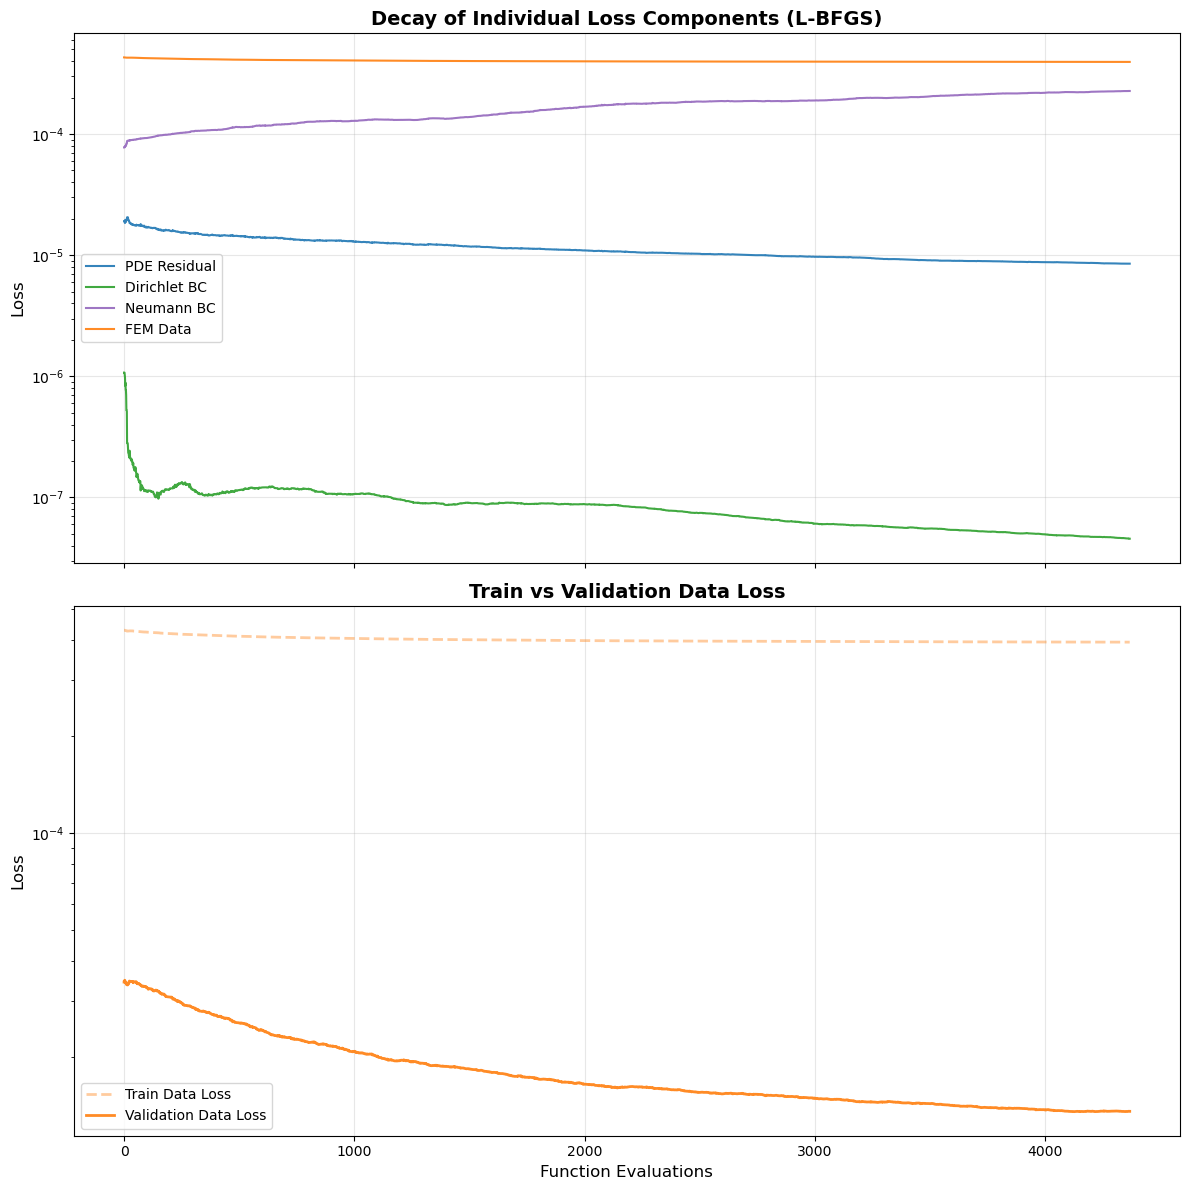

In [7]:
history_lbfgs_clean = plot_lbfgs_history(trainer.history_lbfgs)

Generating map for scar at: (0.5, 0.5)


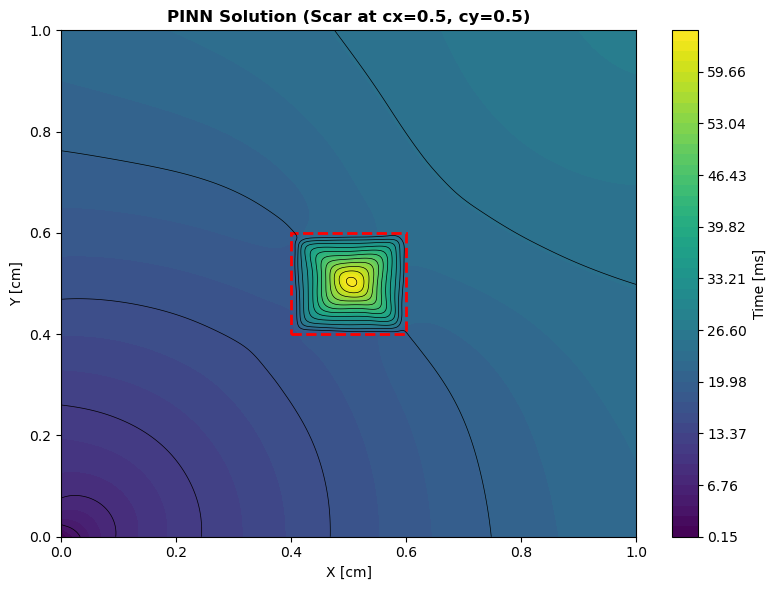

In [8]:
# 1. Select scar center for testing
cx_test = 0.5
cy_test = 0.5
print(f"Generating map for scar at: ({cx_test}, {cy_test})")

# 2. Create a grid for plotting
N_plot = 400 
x_val = np.linspace(0, 1, N_plot)
y_val = np.linspace(0, 1, N_plot)
X, Y = np.meshgrid(x_val, y_val)

# 3. Create tensor for the model input
X_flat_1D = X.flatten()
Y_flat_1D = Y.flatten()
cx_array = np.full_like(X_flat_1D, cx_test)
cy_array = np.full_like(Y_flat_1D, cy_test)

X_flat_4D = np.column_stack((X_flat_1D, Y_flat_1D, cx_array, cy_array))

# 4. Prediction using the trained model
u_pred_flat = model(tf.convert_to_tensor(X_flat_4D, dtype=number_type)).numpy() * U_SCALE
U_PINN = u_pred_flat.reshape(N_plot, N_plot) * 1000.0

# 5. Plot 
plot_parametric_pinn_solution(
    X_fem=X, 
    Y_fem=Y, 
    U_pinn2D=U_PINN, 
    cx_test=cx_test, 
    cy_test=cy_test,
    # title=f"PINN Solution Adam (Scar at cx={cx_test}, cy={cy_test})"  # Titolo personalizzato!
)

In [9]:
from src.utils.metrics import compute_test_metrics
# ground truth FEM solution for the same scar center
data_test = np.load('data/fem/fem_parametric_test.npz')
coords_test = data_test['coords']   
values_test = data_test['values']   

# 2. Compute test metrics
l2_error, mae_error = compute_test_metrics(
    model=model, 
    coords_test=coords_test, 
    values_test=values_test, 
    U_SCALE=U_SCALE, 
    dtype=number_type
)

l2 Relative Error vs FEM Ground Truth: 1.2307%
Mean Absolute Error (Physical): 0.1442 ms
